In [14]:
import os 
print(os.getcwd())
os.chdir("../code/SPID_code")

print(os.getcwd())

c:\GitHub\GGSpeciale\code\SPID_code


FileNotFoundError: [WinError 3] The system cannot find the path specified: '../code/SPID_code'

In [15]:
import socket

print("Host:", socket.gethostname())
print("SLURM job:", os.environ.get("SLURM_JOB_ID"))

Host: SofiesPC
SLURM job: None


In [16]:
from gmDAGGER import train_spid
from stable_baselines3 import PPO

In [17]:
#import PySRWrapper
#reload(PySRWrapper)
from PySRWrapper import PySRPolicy
from stable_baselines3.common.env_util import make_vec_env

env = make_vec_env("MountainCarContinuous-v0", n_envs=1, env_kwargs={})
policy = PySRPolicy(env)

In [36]:
import warnings

from stable_baselines3 import PPO
from gym_pybullet_drones.envs.HoverAviary import HoverAviary
from gym_pybullet_drones.utils.enums import ObservationType, ActionType
import gymnasium as gym
import numpy as np

warnings.filterwarnings(
    "ignore",
    message="You are trying to run PPO on the GPU"
)

warnings.filterwarnings(
    "ignore",
    message="Note: it looks like you are running in Jupyter"
)

# example

# rewards, best_policy, wrapper, run_dir = train_spid(r"/home/ashc/GGSpeciale/ashc_repo/GGSpeciale/code/baseline_code/baseline_models/cartpole/PPO_cartpole.zip", PPO, "", "CartPole-v1", n_iter=1, total_timesteps=3, verbose=2)

teacher_model_path = r"C:\GitHub\GGSpeciale\quadcopter-suite\results\save-04.10.2026_15.39.13\best_model.zip"
teacher_model = PPO
environment = HoverAviary # ContinuousCartPoleEnv #"Swimmer-v5" # or use string like CartPole-v1

DEFAULT_OBS = ObservationType('kin') # 'kin' or 'rgb'
DEFAULT_ACT = ActionType('one_d_rpm') # 'rpm' or 'pid' or 'vel' or 'one_d_rpm' or 'one_d_pid'

class HoverActionShapeWrapper(gym.Wrapper):
    def step(self, action):
        action = np.asarray(action, dtype=np.float32)
        if action.ndim == 1:
            action = action.reshape(1, -1)
        return self.env.step(action)

environment = lambda: HoverActionShapeWrapper(
    HoverAviary(
        obs=DEFAULT_OBS,
        act=DEFAULT_ACT,
        gui=False
    )
)

rewards, best_policy, wrapper, run_dir = train_spid(teacher_path = teacher_model_path, 
                                                    teacher_model = teacher_model, 
                                                    save_folder_path="C:/GitHub/GGSpeciale/quadcopter-suite/distil-results_1000x12", 
                                                    save_results=True, 
                                                    environment=environment, 
                                                    n_iter=12, 
                                                    total_timesteps=12*1000, 
                                                    n_eval_episodes=10,
                                                    verbose=2)

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
Loaded local teacher from: C:\GitHub\GGSpeciale\quadcopter-suite\results\save-04.10.2026_15.39.13\best_model.zip


c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


finished collecting trajectories
computing advantages
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
training
Evaluating trained model
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Iteration 0: student reward = 333.8626 +/- 0.0000
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
Loaded local teacher from: C:\GitHub\GGSpeciale\quadcopter-suite\results\save-04.10.2026_15.39.13\best_model.zip


...

Evaluating trained model
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Iteration 11: student reward = 333.8626 +/- 0.0000
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
Loaded local teacher from: C:\GitHub\GGSpeciale\quadcopter-suite\results\save-04.10.2026_15.39.13\best_model.zip


c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
SPID iteration complete. Dataset size: 3
Best policy iteration: 2
Best student reward during search: 475.1036
Teacher eval: 474.1320 +/- 0.0000
Student eval: 475.1036 +/- 0.0000
Saved results to: C:\GitHub\GGSpeciale\quadcopter-suite\distil-results_1000x12


In [40]:
import time
DEFAULT_OBS = ObservationType("kin")
DEFAULT_ACT = ActionType("one_d_rpm")


class HoverActionShapeWrapper(gym.Wrapper):
    def step(self, action):
        action = np.asarray(action, dtype=np.float32)
        if action.ndim == 1:
            action = action.reshape(1, -1)
        return self.env.step(action)


env = HoverActionShapeWrapper(
    HoverAviary(
        obs=DEFAULT_OBS,
        act=DEFAULT_ACT,
        gui=True,
    )
)

obs, info = env.reset()

episode_reward = 0.0

for t in range(2000):
    # PySRPolicy.predict expects batch-style input
    action, _ = wrapper.predict(obs, deterministic=True)

    # For a single non-vec env, unwrap batch dimension
    action = np.asarray(action, dtype=np.float32)
    if action.ndim == 2 and action.shape[0] == 1:
        action = action[0]

    obs, reward, terminated, truncated, info = env.step(action)
    episode_reward += reward

    time.sleep(1 / 60)  # adjust for display speed

    if terminated or truncated:
        print("Episode reward:", episode_reward)
        obs, info = env.reset()
        episode_reward = 0.0

env.close()

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


error: Only one local in-process GUI/GUI_SERVER connection allowed. Use DIRECT connection mode or start a separate GUI physics server (ExampleBrowser, App_SharedMemoryPhysics_GUI, App_SharedMemoryPhysics_VR) and connect over SHARED_MEMORY, UDP or TCP instead.

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


error: Only one local in-process GUI/GUI_SERVER connection allowed. Use DIRECT connection mode or start a separate GUI physics server (ExampleBrowser, App_SharedMemoryPhysics_GUI, App_SharedMemoryPhysics_VR) and connect over SHARED_MEMORY, UDP or TCP instead.

In [34]:
for i, policy in enumerate(best_policy.policy_list):
    print(f"\n=== Action dimension {i} ===")

    sr = policy.sr
    
    best_eq = sr.get_best()["equation"]
    print("\nBest equation:")
    print(best_eq)



=== Action dimension 0 ===

Best equation:
((0.6180562 - x2) * 0.17343733) + (((x26 - -0.084623665) - (x8 * 0.2812287)) / 1.0788227)


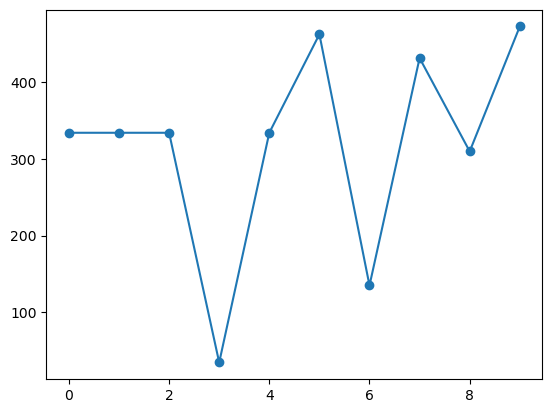

In [35]:
import matplotlib.pyplot as plt

plt.plot(range(len(rewards)), rewards)
plt.scatter(range(len(rewards)), rewards)